<a href="https://colab.research.google.com/github/adishup/gen-ai-lab/blob/main/experiment11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
For faster execution use Runtime > Change runtime type > T4 GPU.

Loading text generation model...


tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Stable Diffusion model loaded successfully!

Enter a content topic: Generative Artificial Intelligence

Generating text...

Generating image...
Please wait...


  0%|          | 0/20 [00:00<?, ?it/s]


GENERATED TEXT
                                                                                         


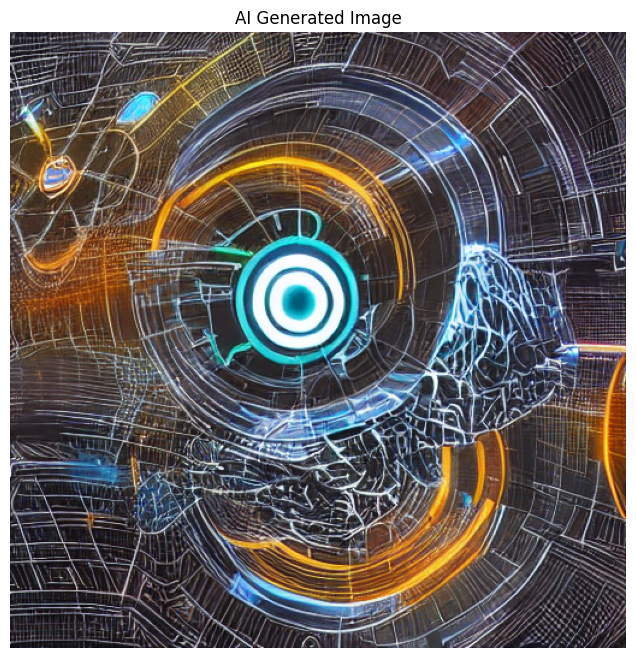


RESULT
AI-based content generation completed successfully.
Image saved as: generated_content_image.png


In [ ]:
# ============================================================
# AI-BASED CONTENT GENERATION SYSTEM
# Text + Image Generation
# ============================================================

# Install required libraries
!pip install -q transformers diffusers accelerate torch pillow matplotlib sentencepiece

# Import libraries
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from diffusers import StableDiffusionPipeline

# ------------------------------------------------------------
# 1. Select device
# ------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

if device == "cpu":
    print("WARNING: You are using CPU. Image generation may take a long time.")
    print("For faster execution use Runtime > Change runtime type > T4 GPU.")

# ------------------------------------------------------------
# 2. Load pretrained language model
# ------------------------------------------------------------
print("\nLoading text generation model...")

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

text_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
)

text_model = text_model.to(device)

print("Text generation model loaded successfully!")

# ------------------------------------------------------------
# 3. Load Stable Diffusion model
# ------------------------------------------------------------
print("\nLoading Stable Diffusion model...")
print("Please wait...")

image_generator = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)

image_generator = image_generator.to(device)

if device == "cuda":
    image_generator.enable_attention_slicing()

print("Stable Diffusion model loaded successfully!")

# ------------------------------------------------------------
# 4. Accept topic from user
# ------------------------------------------------------------
topic = input("\nEnter a content topic: ")

# ------------------------------------------------------------
# 5. Generate textual content
# ------------------------------------------------------------
text_prompt = f"""
Write a short article of about 120 words on the topic:
{topic}

Include:
1. Introduction
2. Importance
3. Applications
"""

print("\nGenerating text...")

inputs = tokenizer(
    text_prompt,
    return_tensors="pt",
    truncation=True
).to(device)

outputs = text_model.generate(
    **inputs,
    max_new_tokens=180,
    do_sample=False
)

generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

# ------------------------------------------------------------
# 6. Create image prompt
# ------------------------------------------------------------
image_prompt = f"""
A realistic high-quality illustration representing {topic},
professional digital art,
highly detailed,
futuristic technology,
cinematic lighting,
4K quality
"""

# ------------------------------------------------------------
# 7. Generate image
# ------------------------------------------------------------
print("\nGenerating image...")
print("Please wait...")

generated_image = image_generator(
    prompt=image_prompt,
    num_inference_steps=20
).images[0]

# ------------------------------------------------------------
# 8. Save image
# ------------------------------------------------------------
image_filename = "generated_content_image.png"

generated_image.save(image_filename)

# ------------------------------------------------------------
# 9. Display generated text
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("GENERATED TEXT")
print("=" * 60)

print(generated_text)

# ------------------------------------------------------------
# 10. Display generated image
# ------------------------------------------------------------
plt.figure(figsize=(8, 8))
plt.imshow(generated_image)
plt.axis("off")
plt.title("AI Generated Image")
plt.show()

# ------------------------------------------------------------
# 11. Result
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RESULT")
print("=" * 60)

print("AI-based content generation completed successfully.")
print("Image saved as:", image_filename)